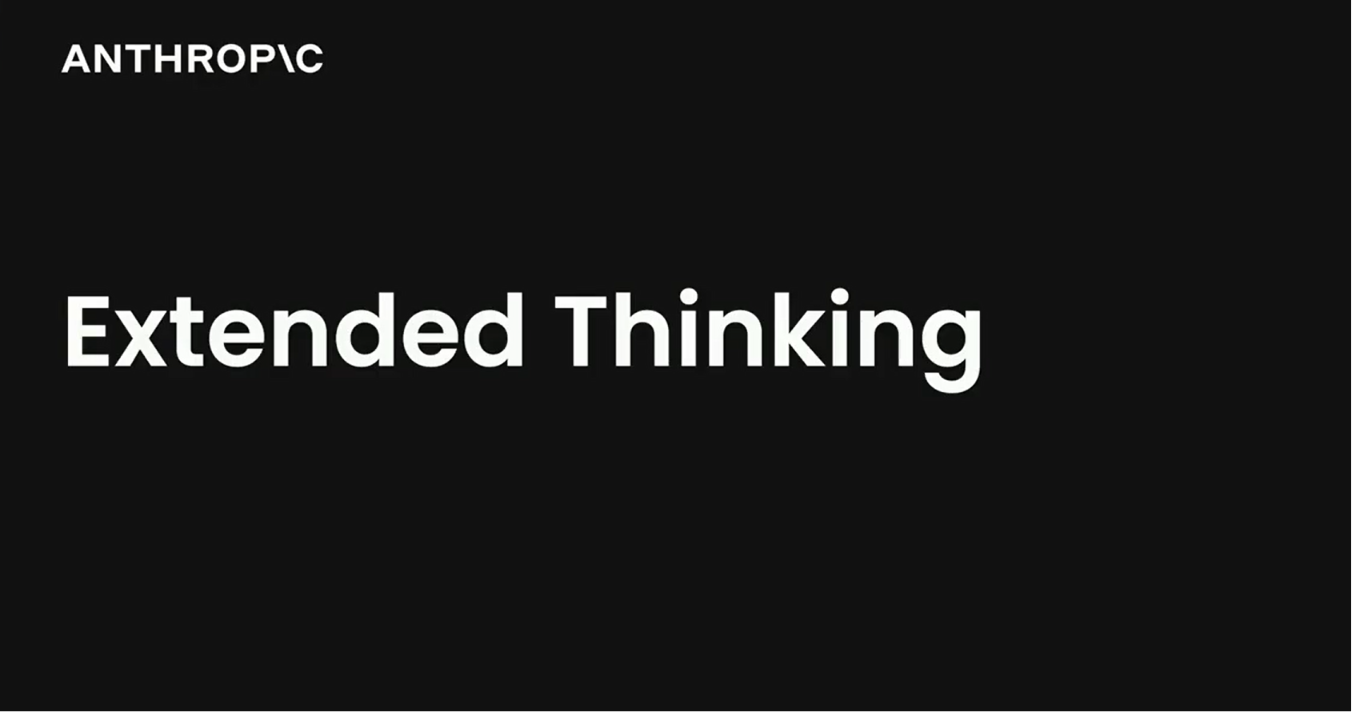

## Extended Thinking

### What Is It?
Extended thinking gives Claude a "scratch pad" to reason through problems before answering. You can see the reasoning process, which improves accuracy on hard problems and adds transparency.

### Response Structure
Instead of just a text block, you get two parts:

- **Thinking block** — Claude's reasoning process
- **Text block** — the final answer

Thinking blocks have a cryptographic signature so you can't tamper with them. If you modify the reasoning, Claude won't trust it.

### Redacted Thinking
Sometimes the thinking block comes back encrypted. This happens when internal safety systems flag the content. You can still pass it back to Claude in future turns — it decodes it internally.

### When to Use It
Don't reach for it immediately. Run your prompts without thinking first. If accuracy still isn't good enough after prompt optimization, then enable it. It costs more and is slower.

### Two New Parameters

- `thinking=True/False` — enables the feature
- `thinking_budget` — max tokens for reasoning, minimum 1024. Must be less than `max_tokens`.

In [3]:
import anthropic
from dotenv import load_dotenv

load_dotenv()
client = anthropic.Anthropic()
model = "claude-sonnet-4-6"

In [4]:
def chat(messages, system=None, temperature=1.0, stop_sequences=[], tools=None, thinking=False, thinking_budget=1024):
    params = {
        "model": model,
        "max_tokens": max(thinking_budget * 2, 2048),
        "messages": messages,
        "stop_sequences": stop_sequences,
    }
    if system:
        params["system"] = system
    if tools:
        params["tools"] = tools
    if thinking:
        params["thinking"] = {"type": "enabled", "budget_tokens": thinking_budget}
    else:
        params["temperature"] = temperature

    return client.messages.create(**params)

In [5]:
messages = [{"role": "user", "content": "What is 27 * 453? Think carefully."}]
response = chat(messages, thinking=True)

for block in response.content:
    if block.type == "thinking":
        print("THINKING:\n", block.thinking[:300], "...\n")
    elif block.type == "text":
        print("ANSWER:\n", block.text)

THINKING:
 27 * 453

27 * 400 = 10,800
27 * 53 = 27 * 50 + 27 * 3 = 1,350 + 81 = 1,431

10,800 + 1,431 = 12,231 ...

ANSWER:
 ## Calculating 27 × 453

I'll break this down into manageable parts:

**27 × 400** = 10,800
**27 × 50** = 1,350
**27 × 3** = 81

**Adding together:**
10,800 + 1,350 + 81 = **12,231**
